In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Dataset directory
DATASET_DIR = Path("/Users/nedamohseni/Downloads/SoLo_dataset")

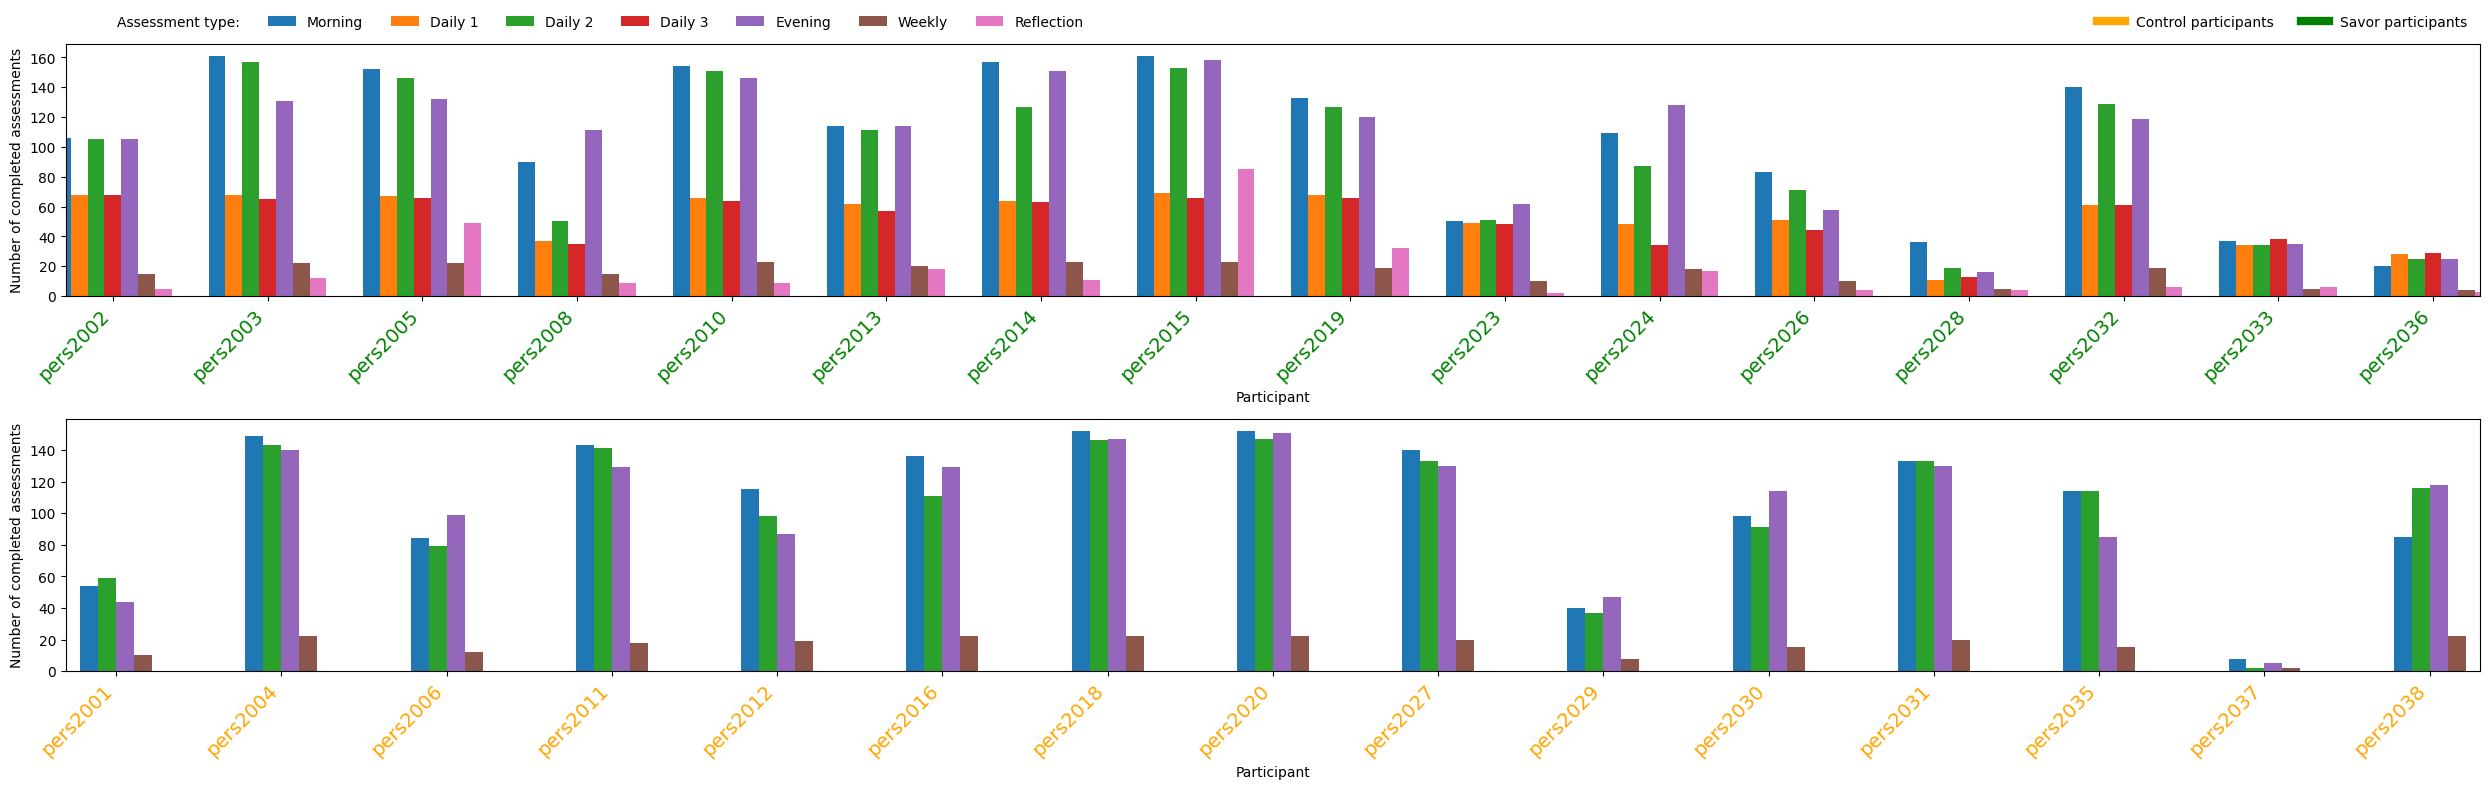

In [12]:
control = ["pers2001","pers2004","pers2006","pers2011","pers2012","pers2016","pers2018","pers2020","pers2027","pers2029","pers2030","pers2031","pers2035","pers2037","pers2038"]
savor = ["pers2002","pers2003","pers2005","pers2008","pers2010","pers2013","pers2014","pers2015","pers2019","pers2023","pers2024","pers2026","pers2028","pers2032","pers2033","pers2036"]
participants = control + savor

records = []

for participant_dir in sorted(DATASET_DIR.iterdir()):
    if not participant_dir.is_dir():
        continue
    participant = participant_dir.name
    self_report = participant_dir / "Self_Report"
    ema_path = self_report / "ema_daily.csv"
    weekly_path = self_report / "weekly_questionnaires.csv"
    reflection_path = self_report / "reflection_activity.csv"
    if ema_path.exists():
        ema = pd.read_csv(ema_path)
        ema_counts = ema["surveyindex"].value_counts()
        records.append({"participant": participant, "Morning": ema_counts.get(0, 0), "Daily 1": ema_counts.get(1, 0), "Daily 2": ema_counts.get(2, 0), "Daily 3": ema_counts.get(3, 0), "Evening": ema_counts.get(4, 0), "Weekly": len(pd.read_csv(weekly_path)) if weekly_path.exists() else 0, "Reflection": len(pd.read_csv(reflection_path)) if reflection_path.exists() else 0})

counts = pd.DataFrame(records).set_index("participant").reindex(participants, fill_value=0)

control_types = ["Morning", "Daily 2", "Evening", "Weekly"]
savor_types = ["Morning", "Daily 1", "Daily 2", "Daily 3", "Evening", "Weekly", "Reflection"]

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
assessment_colors = dict(zip(savor_types, colors))

# assessment_colors = {
#     "Morning": "#4E79A7",
#     "Daily 1": "#76B7B2",
#     "Daily 2": "#B07AA1",
#     "Daily 3": "#E15759",
#     "Evening": "#F28E2B",
#     "Weekly": "#7F7F7F",
#     "Reflection": "#EDC948"
# }

fig, axes = plt.subplots(2, 1, figsize=(25, 8))

ax = axes[0]
savor_counts = counts.loc[savor]
x = np.arange(len(savor_counts)) * 1.15
width = 0.125

for j, participant in enumerate(savor_counts.index):
    offsets = (np.arange(len(savor_types)) - (len(savor_types) - 1) / 2) * width
    for offset, assessment in zip(offsets, savor_types):
        ax.bar(x[j] + offset, savor_counts.loc[participant, assessment], width, color=assessment_colors[assessment])

ax.set_xlim(x[0] - 0.35, x[-1] + 0.35)
ax.set_xlabel("Participant")
ax.set_ylabel("Number of completed assessments")
ax.set_xticks(x)
ax.set_xticklabels(savor_counts.index, rotation=45, ha="right")
ax.tick_params(axis="x", labelsize=14)

for tick in ax.get_xticklabels():
    tick.set_color("green")

legend1 = ax.legend(handles=[Patch(facecolor="none", edgecolor="none", label="Assessment type:")] + [Patch(facecolor=assessment_colors[a], label=a) for a in savor_types], frameon=False, loc="lower left", bbox_to_anchor=(0, 1.01), ncol=8)
ax.legend(handles=[Line2D([0], [0], color="orange", lw=6, label="Control participants"), Line2D([0], [0], color="green", lw=6, label="Savor participants")], frameon=False, loc="lower right", bbox_to_anchor=(1, 1.01), ncol=2)
ax.add_artist(legend1)

ax = axes[1]
control_counts = counts.loc[control]
x = np.arange(len(control_counts)) * 1.15
width = 0.125

for j, participant in enumerate(control_counts.index):
    offsets = (np.arange(len(control_types)) - (len(control_types) - 1) / 2) * width
    for offset, assessment in zip(offsets, control_types):
        ax.bar(x[j] + offset, control_counts.loc[participant, assessment], width, color=assessment_colors[assessment])

ax.set_xlim(x[0] - 0.35, x[-1] + 0.35)
ax.set_xlabel("Participant")
ax.set_ylabel("Number of completed assessments")
ax.set_xticks(x)
ax.set_xticklabels(control_counts.index, rotation=45, ha="right")
ax.tick_params(axis="x", labelsize=14)

for tick in ax.get_xticklabels():
    tick.set_color("orange")

plt.tight_layout()
plt.savefig("assessment_counts.png", dpi=300, bbox_inches="tight")
plt.show()